# Riesgo de crédito - Modelos para estimar probabilidad de impago

Vamos a centrarnos en la estimación de la probabilidad de impago para calcular la perdida esperada.

## Regresión logística

Se emplea ampliamente para modelar, y estimar la probabilidad de impago en la administración del riesgo de crédito.

Esta regresión es muy similar en muchas características a la regresión lineal, la diferencia es que el valor estimado por el modelo esta siempre entre $0$ y $1$.

Esto es necesario ya que estamos interesados en predecir cual es la probabilidad de impago que, por definición de lo que es una probabilidad, esta entre $0$ y $1$.

$$
P(\text{LS} = 1|x_1, \dots , x_m) = \frac{1}{1+e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_m x_m)}}
$$

En un modelo de regresión logística, la probabilidad de impago se puede escribir como la probabilidad de que el estado de la deuda sea igual a $1$, condicionado a las variables $X_1, \dots, X_m$.

Adicionalmente, los parámetros $\beta_0, \dots , \beta_m$ deben de ser estimados.

La combinación de los parámetros y las variables se conoce como un predictor lineal.

### Estimación

Se puede ajustar un modelo de regresión logística en Python usando el comando `Logit` de la librería `statsmodels`

Por ejemplo, para usar como variable explicativa únicamente la edad, se tiene el modelo:

$$
P(\text{LS} = 1|\text{edad}) = \frac{1}{1+e^{-(\hat\beta_0 + \hat\beta_1 \text{edad})}}
$$

Emplearemos la misma base de datos que veníamos usando, pero eliminando la observación atípica de ingresos anuales y creando variables categóricas para la tasa de interés y el tiempo como empleado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib import colors
from pandas.api.types import CategoricalDtype
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from scipy.stats import randint

In [2]:
link = "https://raw.githubusercontent.com/salas317/Data/main/GRF/loan_data.csv"
loan_data = pd.read_csv(filepath_or_buffer = link, index_col = 0)
loan_data

,loan_status,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,age,emp_cat,ir_cat
1,0,5000,10.65,B,10.0,RENT,24000.0,33,8+,8-11
2,0,2400,NaN,C,25.0,RENT,12252.0,31,8+,Missing
3,0,10000,13.49,C,13.0,RENT,49200.0,24,8+,11-13.5
4,0,5000,NaN,A,3.0,RENT,36000.0,39,2-4,Missing
5,0,3000,NaN,E,9.0,RENT,48000.0,24,8+,Missing
...,...,...,...,...,...,...,...,...,...,...
29088,0,2500,8.07,A,4.0,MORTGAGE,110000.0,27,2-4,8-11
29089,0,8500,10.28,C,3.0,RENT,18000.0,25,2-4,8-11
29090,0,5000,8.07,A,0.0,MORTGAGE,100000.0,27,0-2,8-11
29091,0,5000,7.43,A,0.0,MORTGAGE,200000.0,23,0-2,0-8


Ajustemos la variables categóricas y creemos las dos variables auxiliares para conservar las observaciones con datos omitidos en el caso del tiempo como empleado y la tasa de interés.

In [3]:
loan_data["home_ownership"] = loan_data["home_ownership"].astype("category")

cat_type = CategoricalDtype(categories = list("GFEDCBA"), ordered=True, )
loan_data["grade"] = loan_data["grade"].astype(cat_type)

cat_type = CategoricalDtype(categories = ["Missing", "0-2", "2-4", "4-8", "8+"], ordered=True, )
loan_data["emp_cat"] = loan_data["emp_cat"].astype(cat_type)

cat_type = CategoricalDtype(categories = ["Missing", "0-8", "8-11", "11-13.5", "13.5+"], ordered=True, )
loan_data["ir_cat"] = loan_data["ir_cat"].astype(cat_type)

print("Tipos de datos:\n")
print(loan_data.dtypes)
print("-----------------\n")
print("Datos omitidos:\n")
print(loan_data.isna().sum())

Tipos de datos:

loan_status          int64
loan_amnt            int64
int_rate           float64
grade             category
emp_length         float64
home_ownership    category
annual_inc         float64
age                  int64
emp_cat           category
ir_cat            category
dtype: object
-----------------

Datos omitidos:

loan_status          0
loan_amnt            0
int_rate          2776
grade                0
emp_length         809
home_ownership       0
annual_inc           0
age                  0
emp_cat              0
ir_cat               0
dtype: int64


Vamos a dividir la base de datos considerando 2/3 de la base para entrenamiento y el resto para evaluar el modelos.

In [4]:
train_set, test_set = train_test_split(loan_data, test_size = 1/3, random_state = 567)

Ahora vamos a estimar nuestro modelo logit empleando la libreria statsmodels.

In [5]:
modelo_logit = smf.logit(formula = "loan_status ~ age", data = train_set).fit()
print(modelo_logit.summary())

Optimization terminated successfully.
         Current function value: 0.347245
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                19394
Model:                          Logit   Df Residuals:                    19392
Method:                           MLE   Df Model:                            1
Date:                Tue, 06 Oct 2026   Pseudo R-squ.:               0.0005826
Time:                        18:27:01   Log-Likelihood:                -6734.5
converged:                       True   LL-Null:                       -6738.4
Covariance Type:            nonrobust   LLR p-value:                  0.005076
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.7908      0.109    -16.416      0.000      -2.005      -1.577
age           -0.0107      0.

### Odds

Hemos visto la expresión relacionada a la probabilidad de impago. Si se multiplica esta expresión por la exponencial del predictor lineal ($e^{\beta_0 + \beta_1 x_1 + \dots + \beta_m x_m}$), tanto en el numerador como en el denominador, se obtiene:

$$
P(\text{LS} = 1|x_1, \dots , x_m) = \frac{1}{1+e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_m x_m)}} = \frac{e^{\beta_0 + \beta_1 x_1 + \dots + \beta_m x_m}}{1+e^{\beta_0 + \beta_1 x_1 + \dots + \beta_m x_m}}
$$

$$
P(\text{LS} = 0|x_1, \dots , x_m) = 1 - \frac{e^{\beta_0 + \beta_1 x_1 + \dots + \beta_m x_m}}{1+e^{\beta_0 + \beta_1 x_1 + \dots + \beta_m x_m}} = \frac{1}{1+e^{\beta_0 + \beta_1 x_1 + \dots + \beta_m x_m}}
$$

$$
\frac{P(\text{LS} = 1|x_1, \dots , x_m)}{P(\text{LS} = 0|x_1, \dots , x_m)} = e^{\beta_0 + \beta_1 x_1 + \dots + \beta_m x_m}
$$

Esto se conoce como *odds* en favor de `loan_status = 1`

#### Interpretación de los coeficientes bajo en enfoque de los odds

- Si la variable $x_j$ aumenta en una unidad entonces los odds se multiplican por $e^{\beta_j}$.

- Si $\beta_j < 0$, entonces $e^{\beta_j}<1$, por lo tanto, el odds disminuye a medida que aumenta $x_j$.

- Si $\beta_j > 0$, entonces $e^{\beta_j}>1$, por lo tanto, el odds aumenta a medida que $x_j$ crece.

En nuestro modelo de ejemplo:

Si la edad aumenta en $1$ año, entonces los odds se multiplican por $e^{-0.0107}$. Esto quiere decir que disminuyen a medida que aumenta la edad.

In [6]:
odd_edad = np.exp(modelo_logit.params.iloc[1]) # modelo_logit.params trae los coeficientes estimados del modelo

print(f"O sea que los odds se multiplican por {odd_edad:.4f}, o {odd_edad:.4%}. Esto es lo mismo que decir que por cada año adicional, los odds de impago disminuyen en un {(1-odd_edad):.4%}.")

O sea que los odds se multiplican por 0.9893, o 98.9337%. Esto es lo mismo que decir que por cada año adicional, los odds de impago disminuyen en un 1.0663%.


### Efectos marginales

Otra forma de ver como una variable afecta la probabilidad de impago es por medio del cálculo de los efectos marginales.

Estos efectos miden el efecto promedio directo en la probabilidad de impago, a diferencia de efecto en los odds que miden el efecto en la relación, del aumento en una unidad en la variable explicativa.

Para nuestro modelo de ejemplo se tiene:

In [7]:
marginal_effects = modelo_logit.get_margeff()
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:            loan_status
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
age           -0.0011      0.000     -2.753      0.006      -0.002      -0.000


Lo que quiere decir que, en promedio, aumentar la edad en un año, disminuye la probabilidad de impago en 0.11% puntos porcentuales.

### Uso de variables categóricas en el modelo

Cuando se incluye una variable categórica en un modelo logístico, se obtiene una estimación de un parámetro para todas las categorías, excepto una. Esta categoría se conoce como categoría de referencia.

El parámetro estimado de las demás categorías representa el cambio en el odd ratio de default entre la categoría de interés y la categoría de referencia.

VVamos a trabajar con un ejemplo sencillo, usando como variables predictoras `age` y `home_ownership`.

$$
P(\text{LS} = 1 | \text{age, home\_ownership}) = \frac{1}{1+e^{-(\hat\beta_0+\hat\beta_1\text{age}+\hat\beta_2\text{OTHER}+\hat\beta_3\text{OWN}+\hat\beta_4\text{RENT})}}
$$

In [8]:
modelo_logit_small = smf.logit(formula = "loan_status ~ age + home_ownership", data = train_set).fit()
print(modelo_logit_small.summary())

Optimization terminated successfully.
         Current function value: 0.346688
         Iterations 6


                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                19394
Model:                          Logit   Df Residuals:                    19389
Method:                           MLE   Df Model:                            4
Date:                Tue, 06 Oct 2026   Pseudo R-squ.:                0.002186
Time:                        18:27:01   Log-Likelihood:                -6723.7
converged:                       True   LL-Null:                       -6738.4
Covariance Type:            nonrobust   LLR p-value:                 6.285e-06
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -1.9379      0.114    -17.041      0.000      -2.161      -1.715
home_ownership[T.OTHER]     0.5257      0.346      1.517      0.129      -0.153       1.205


Podemos ver que la categoría `MORTGAGE` no esta en los resultados del modelo, esto quiere decir que esta es la categoría base. La constante hace referencia a las personas que viven en casa con hipoteca. Los valores de los coeficientes asociados a las demás categorías hacen referencia a si la probabilidad de caer en default aumenta o disminuye en comparación con las personas que viven en hipoteca.

### Estimación de la probabilidad de incumplimiento.

Ya sabemos cómo estimar nuestro modelo de regresión logística para la probabilidad de incumplimiento en los pagos.

Ahora bien, lo que nos interesa del modelo es: ¿Cómo lo usamos para predecir la probabilidad de incumplimiento de los clientes, tanto los que se usaron en el entrenamiento como los que se dejaron para probar el modelo?

Vamos a trabajar con el modelo que acabamos de estimar. Observemos las características del primer usuario en la base de datos de pruebas y, a partir de estas, estimemos la probabilidad de que incumpla con los pagos.

In [9]:
test_set.head(1)

,loan_status,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,age,emp_cat,ir_cat
25348,0,1200,11.89,B,1.0,RENT,13000.0,24,0-2,11-13.5


Según nuestro modelo estimado, la probabilidad de no cumplir con los pagos seria:

$$
P(\text{LS} = 1 | \text{age} = 24, \text{home\_ownership} = \text{RENT}) = \frac{1}{1+e^{-(\hat\beta_0+\hat\beta_1\times 24 +\hat\beta_2\times 0 +\hat\beta_3\times 0 +\hat\beta_4\times 1 )}}
$$

$$
P(\text{LS} = 1 | \text{age} = 24, \text{home\_ownership} = \text{RENT}) = \frac{1}{1+e^{-(\hat\beta_0+\hat\beta_1\times 24 +\hat\beta_4\times 1 )}}
$$

$$
P(\text{LS} = 1 | \text{age} = 24, \text{home\_ownership} = \text{RENT}) = \frac{1}{1+e^{-(-1.9379 + (-0.0101 \times 24) + 0.2168 \times 1 )}}
$$

No es algo sencillo de calcular, asi que vamos a pedirle a Python que lo haga por nosotros.

In [10]:
prob = modelo_logit_small.predict(exog = test_set.head(1)).to_numpy()[0]
odds = prob / (1 - prob)
prob
print(f"La probabilidad esperada de entrar en default que tiene una persona de 24 años y que vive en arriendo es de: {prob:.2%}")
print(f"Los odds son de {odds:.4f}. Es decir {odds:.4f} a 1 a favor de que la persona entre en default. Es igual que {1/odds:.4f} a 1 en contra de que la persona no entre en default.")

La probabilidad esperada de entrar en default que tiene una persona de 24 años y que vive en arriendo es de: 12.30%
Los odds son de 0.1403. Es decir 0.1403 a 1 a favor de que la persona entre en default. Es igual que 7.1295 a 1 en contra de que la persona no entre en default.


## Otros modelos para estimar probabilidad

El modelo logit no es el único modelo que se puede emplear para calcular una probabilidad de impago. Se pueden emplear otros modelos como los son:

- Modelo probabilístico lineal (MPL)

- Modelo probit

El MPL no se emplea con frecuencia, dado que puede obtener probabilidades menores que 0 o mayores que 1. Para estimar un modelo probit tenemos:

In [11]:
modelo_probit_small = smf.probit(formula = "loan_status ~ age + home_ownership", data = train_set).fit()
print(modelo_probit_small.summary())

Optimization terminated successfully.
         Current function value: 0.346688
         Iterations 6


                          Probit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                19394
Model:                         Probit   Df Residuals:                    19389
Method:                           MLE   Df Model:                            4
Date:                Tue, 06 Oct 2026   Pseudo R-squ.:                0.002187
Time:                        18:27:01   Log-Likelihood:                -6723.7
converged:                       True   LL-Null:                       -6738.4
Covariance Type:            nonrobust   LLR p-value:                 6.275e-06
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -1.1479      0.058    -19.710      0.000      -1.262      -1.034
home_ownership[T.OTHER]     0.2789      0.191      1.464      0.143      -0.095       0.652


Los efectos marginales se calculan de manera similar

In [12]:
marginal_effects_probit = modelo_probit_small.get_margeff()
marginal_effects_logit = modelo_logit_small.get_margeff()
print(marginal_effects_probit.summary())
print(marginal_effects_logit.summary())

       Probit Marginal Effects       
Dep. Variable:            loan_status
Method:                          dydx
At:                           overall
                             dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
home_ownership[T.OTHER]     0.0525      0.036      1.464      0.143      -0.018       0.123
home_ownership[T.OWN]       0.0182      0.009      2.095      0.036       0.001       0.035
home_ownership[T.RENT]      0.0212      0.005      4.454      0.000       0.012       0.031
age                        -0.0010      0.000     -2.632      0.008      -0.002      -0.000


        Logit Marginal Effects       
Dep. Variable:            loan_status
Method:                          dydx
At:                           overall
                             dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
home_ownership[T.OTHER]     0.0516      0.034      1.517      0.129      -0.015       0.118
home_ownership[T.OWN]       0.0183      0.009      2.108      0.035       0.001       0.035
home_ownership[T.RENT]      0.0213      0.005      4.430      0.000       0.012       0.031
age                        -0.0010      0.000     -2.609      0.009      -0.002      -0.000


## Uso de modelos para clasificar clientes

Uno de los usos mas frecuente a los modelos de estimación de probabilidad es el de clasificar a los clientes si son viables o no, a partir de su probabilidad de incumplir con los pagos.

En este aspecto los modelos de estimación vistos anteriormente sirven para clasificar, después de definir una regla de decisión que defina una probabilidad mínima a partir de la cual el cliente se considera riesgoso y, por lo tanto, no es recomendable hacer el préstamo.

Adicional a los modelos ya vistos, existen otros tipos de modelos que permiten clasificar a los clientes. Nosotros estudiaremos únicamente el modelo de **bosques de decisión**.

Los bosques de decisión (random forest) son modelos de clasificación diseñados para corregir los problemas de sobreajuste (overfitting) comunes en los arboles de decisión. La idea del modelo es crear una cantidad considerable de arboles diferentes para construir las clasificaciones, se toma el valor que más eligen los árboles en el bosque.

Un ejemplo de un bosque de decisión para nuestros datos es el siguiente:

In [13]:
X_train = train_set[["age", "home_ownership"]]
X_train = pd.get_dummies(data = X_train, columns = ["home_ownership"], drop_first = False, dtype = int) # transformación de las variables categóricas para crear variables dummy
y_train = train_set["loan_status"]

In [14]:
rf_model = RandomForestClassifier(n_estimators=500, random_state = 567)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Para estimar la probabilidad se tiene:

In [15]:
x = test_set[["age", "home_ownership"]]
x = pd.get_dummies(data = x, columns = ["home_ownership"], drop_first = False, dtype = int)
x = x.head(1)

prob_rf = rf_model.predict_proba(x)[:,1][0]
print(f"La probabilidad esperada de entrar en default que tiene una persona de 24 años y que vive en arriendo, según el bosque de decisión, es de: {prob_rf*100:.2f}%")

La probabilidad esperada de entrar en default que tiene una persona de 24 años y que vive en arriendo, según el bosque de decisión, es de: 11.11%


Ademas podemos clasificar automaticamente a nuestro cliente, para decidir si le hacemos el prestamo o no.

In [16]:
preds_rf = rf_model.predict(x)[0]
print(f"El valor estimado de loan_status para una persona de 24 años y que vive en arriendo, según el bosque de decisión, es de: {preds_rf}")

El valor estimado de loan_status para una persona de 24 años y que vive en arriendo, según el bosque de decisión, es de: 0


Vamos a buscar que combinación de la profundidad de cada árbol, y cuantos arboles nos ayudan a encontrar el modelo mas adecuado a nuestros datos de entrenamiento. 

In [17]:
param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}

rf = RandomForestClassifier()

# Usamos random search para encontrar los mejores hyperparametros
rand_search = RandomizedSearchCV(rf, 
                                 param_distributions = param_dist, 
                                 n_iter=30, 
                                 cv=5, 
                                 random_state=847)

# Fit the random search object to the data
rand_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....001652AC3D950>, 'n_estimators': <scipy.stats....001652AC01940>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value i

In [18]:
best_rf = rand_search.best_estimator_

print('Mejores hiperparametros:',  rand_search.best_params_)

Mejores hiperparametros: {'max_depth': 2, 'n_estimators': 414}


In [19]:
prob_rf_best = best_rf.predict_proba(x)[:,1][0]
print(f"La probabilidad esperada de entrar en default que tiene una persona de 24 años y que vive en arriendo, según el bosque de decisión, es de: {prob_rf_best*100:.2f}%")

La probabilidad esperada de entrar en default que tiene una persona de 24 años y que vive en arriendo, según el bosque de decisión, es de: 11.58%


In [20]:
preds_rf_best = best_rf.predict(x)[0]
print(f"El valor estimado de loan_status para una persona de 24 años y que vive en arriendo, según el bosque de decisión, es de: {preds_rf_best}")

El valor estimado de loan_status para una persona de 24 años y que vive en arriendo, según el bosque de decisión, es de: 0


Ahora bien, la pregunta es ¿Cómo decidir cual es el mejor modelo para clasificar a los clientes? Vamos a trabajar en ello.

## Selección del mejor modelo de clasificación

Una primera medida para escoger cual modelo puede ser el mas adecuado para clasificar a los clientes es el uso de las matrices de confusión.

### Matrices de confusión

Primero, se debe de elegir cual va a ser el valor de corte para decidir si un cliente es inviable. Ya que los modelos estiman probabilidades, no categorías. El valor de corte determina que cualquier probabilidad estimada mayor al corte implica que el cliente se debe de catalogar como no aceptable. Para este ejemplo usaremos un valor de $0.1$.

Ahora vamos a construir las matrices para nuestros modelos. Primero calculamos las probabilidades.

In [21]:
X_test = test_set[["age", "home_ownership"]]
X_test = pd.get_dummies(data = X_test, columns = ["home_ownership"], drop_first = False, dtype = int)
y_test = test_set["loan_status"]

probs_logit = modelo_logit_small.predict(exog = test_set)
probs_probit = modelo_probit_small.predict(exog = test_set)
probs_rf = best_rf.predict_proba(X_test)[:, 1]

Ahora, vamos a aplicar un punto de corte de 0.1 para decidir si la persona se clasifica como alguien a quien no se le presta o si, si la probabilidad estimada es mayor o igual al punto de corte se define que no se le debe prestar (se asigna a `loan_status` el valor 1)

In [22]:
threshold = 0.1

preds_logit = (probs_logit >= threshold).astype(int)
preds_probit = (probs_probit >= threshold).astype(int)
preds_rf = (probs_rf >= threshold).astype(int)

Por último, construyamos las matrices de confusión.

Confusion Matrix - Logit:


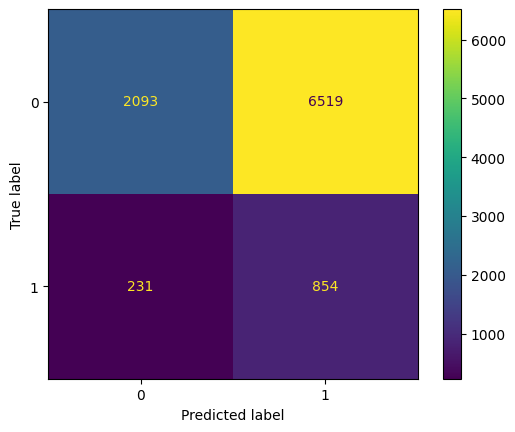

In [23]:
cm_logit = metrics.confusion_matrix(y_test, preds_logit)
cm_probit = metrics.confusion_matrix(y_test, preds_probit)
cm_rf = metrics.confusion_matrix(y_test, preds_rf)

tn_logit, fp_logit, fn_logit, tp_logit = cm_logit.ravel()
tn_probit, fp_probit, fn_probit, tp_probit = cm_probit.ravel()
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print("Confusion Matrix - Logit:")
metrics.ConfusionMatrixDisplay(confusion_matrix=cm_logit).plot()


Confusion Matrix - Probit:


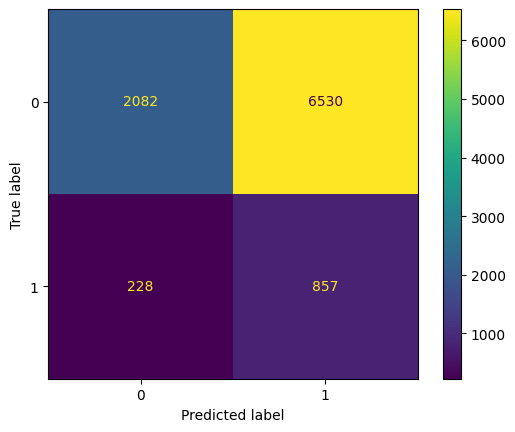

In [24]:
print("\nConfusion Matrix - Probit:")
metrics.ConfusionMatrixDisplay(confusion_matrix=cm_probit).plot()


Confusion Matrix - Random Forest:


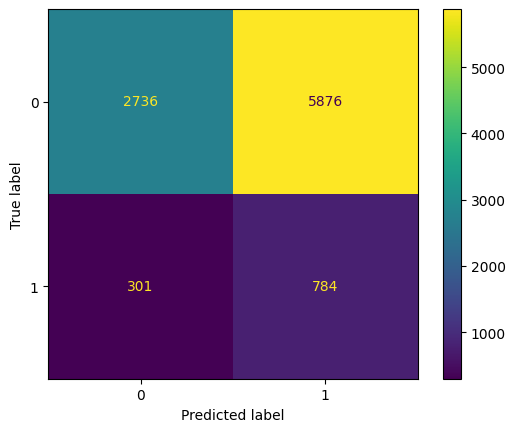

In [25]:
print("\nConfusion Matrix - Random Forest:")
metrics.ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot()

Calculemos la precisión

In [26]:
precision_logit = metrics.accuracy_score(y_test, preds_logit)
precision_probit = metrics.accuracy_score(y_test, preds_probit)
precision_rf = metrics.accuracy_score(y_test, preds_rf)

print(f"La precision del modelo logit es de: {precision_logit:.2%}")
print(f"La precision del modelo probit es de: {precision_probit:.2%}")
print(f"La precision del bosque de decisión es de: {precision_rf:.2%}")

La precision del modelo logit es de: 30.39%
La precision del modelo probit es de: 30.31%
La precision del bosque de decisión es de: 36.30%


Ahora la sensibilidad:

In [27]:
sens_logit = metrics.recall_score(y_test, preds_logit)
sens_probit = metrics.recall_score(y_test, preds_probit)
sens_rf = metrics.recall_score(y_test, preds_rf)

print(f"La sensibilidad del modelo logit es de: {sens_logit:.2%}")
print(f"La sensibilidad del modelo probit es de: {sens_probit:.2%}")
print(f"La sensibilidad del bosque de decisión es de: {sens_rf:.2%}")

La sensibilidad del modelo logit es de: 78.71%
La sensibilidad del modelo probit es de: 78.99%
La sensibilidad del bosque de decisión es de: 72.26%


Y, por último, la especificidad

In [28]:
espec_logit = metrics.recall_score(y_test, preds_logit, pos_label=0)
espec_probit = metrics.recall_score(y_test, preds_probit, pos_label=0)
espec_rf = metrics.recall_score(y_test, preds_rf, pos_label=0)

print(f"La especificidad del modelo logit es de: {espec_logit:.2%}")
print(f"La especificidad del modelo probit es de: {espec_probit:.2%}")
print(f"La especificidad del bosque de decisión es de: {espec_rf:.2%}")

La especificidad del modelo logit es de: 24.30%
La especificidad del modelo probit es de: 24.18%
La especificidad del bosque de decisión es de: 31.77%


## Curva característica de funcionamiento del receptor (ROC) y área bajo la curva (AUC)

Una de las limitaciones que se tiene al momento de emplear las matrices de confusión para elegir el modelo mas adecuado a emplear como método de clasificación es el hecho de que los resultados de las matrices y sus métricas cambian de acuerdo con el valor de corte (cutoff) o umbral que se elija para determinar si el cliente se debe considerar riesgoso o no.

Una idea es la de usar varios cortes diferentes y calcular las matrices, pero este proceso toma mucho tiempo y es dispendioso, aun contando con la ayuda de paquetes estadísticos.

Para resolver esta situación existe un método llamado la curva característica de funcionamiento del receptor (**ROC**). Esta curva permite graficar como, a medida que se cambia el valor del corte desde 0 hasta 1, varia la sensibilidad (o tasa de verdaderos positivos - TPR) y el valor de 1-especificidad (también denominado tasa de falsos positivos - FPR).

Esta curva internamente calcula las matrices de confusión para cada uno de los cortes que se asignen y posteriormente gráfica un punto donde la coordenada $y$ es la tasa de verdaderos positivos y la coordenada $x$ es la tasa de falsos positivos. Estos pasos se repiten para diferentes cortes hasta que se obtiene una curva que empieza en $(0,0)$ y termina en $(1,1)$.

El área bajo la curva (**AUC**) es exactamente eso, el área bajo la curva ROC. Esta área puede tomar un valor máximo de 1, lo que significaría que el modelo funciona de manera perfecta para clasificar a los individuos. Por esta razón se debe de elegir el modelo que tenga un valor de AUC más cercano a 1.

Observemos como lo usamos en nuestro ejemplo de los modelos. Primero calculemos las curvas ROC y el AUC

In [29]:
# Curva ROC
fpr_logit, tpr_logit, thresholds_logit = metrics.roc_curve(y_test, probs_logit)
fpr_probit, tpr_probit, thresholds_probit = metrics.roc_curve(y_test, probs_probit)
fpr_rf, tpr_rf, thresholds_rf = metrics.roc_curve(y_test, probs_rf)

# AUC
auc_logit = metrics.roc_auc_score(y_test, probs_logit)
auc_probit = metrics.roc_auc_score(y_test, probs_probit)
auc_rf = metrics.roc_auc_score(y_test, probs_rf)

print(f"Logit AUC: {auc_logit:.4f}")
print(f"Probit AUC: {auc_probit:.4f}")
print(f"Random forest AUC: {auc_rf:.4f}")

Logit AUC: 0.5332
Probit AUC: 0.5332
Random forest AUC: 0.5345


Realicemos los graficos para cada uno de los modelos por separado.

C:\Users\Andres Londoño P\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:440: FutureWarning: y_pred was deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(


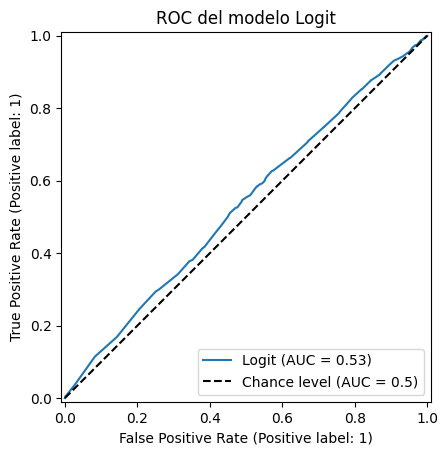

In [30]:
metrics.RocCurveDisplay.from_predictions(y_true = y_test, y_pred= probs_logit, plot_chance_level = True, name = "Logit")
plt.title("ROC del modelo Logit")
plt.show()

C:\Users\Andres Londoño P\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:440: FutureWarning: y_pred was deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(


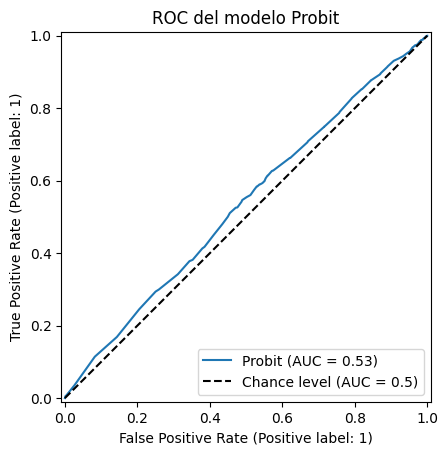

In [31]:
metrics.RocCurveDisplay.from_predictions(y_true = y_test, y_pred = probs_probit, plot_chance_level = True, name = "Probit")
plt.title("ROC del modelo Probit")
plt.show()

C:\Users\Andres Londoño P\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:440: FutureWarning: y_pred was deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(


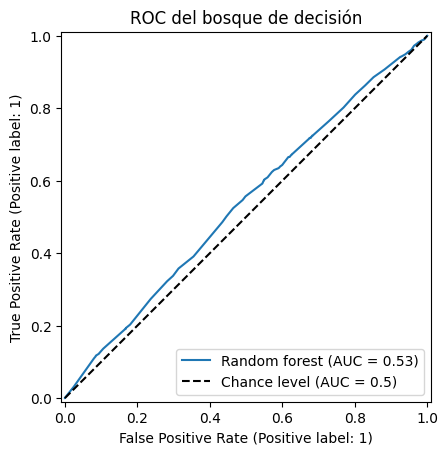

In [32]:
metrics.RocCurveDisplay.from_predictions(y_true = y_test, y_pred = probs_rf, plot_chance_level = True, name = "Random forest")
plt.title("ROC del bosque de decisión")
plt.show()

Ahora hagamos un grafico de los tres modelos juntos

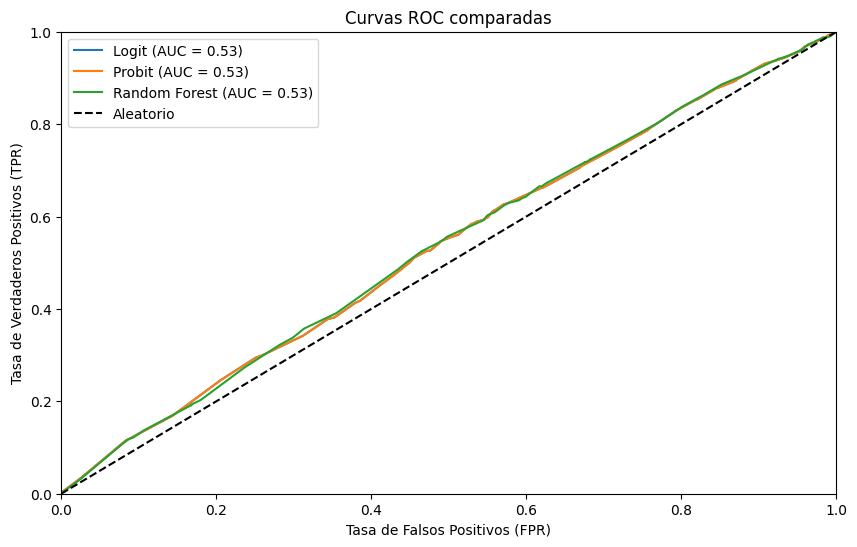

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_logit, tpr_logit, label=f'Logit (AUC = {auc_logit:.2f})')
plt.plot(fpr_probit, tpr_probit, label=f'Probit (AUC = {auc_probit:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC comparadas')
plt.legend()
plt.grid(False)
plt.ylim([0,1])
plt.xlim([0,1])
plt.show()

Se puede observar que el mejor modelo es el bosque de decisión.

Ya sabemos cuál modelo debemos elegir, pero ¿cuál debería ser el punto de corte? Esta pregunta nos la ayuda a responder la curva ROC, hay un elemento llamado “optimal Youden Index point” que muestra el corte que maximiza la distancia entre el TPR y el FPR. Este valor de corte es una recomendación, sin embargo la elección del corte es a discreción del usuario.

In [34]:
def best_cutoff(fpr, tpr, thresholds):
    youden_index = tpr - fpr
    best_idx = np.argmax(youden_index)
    return thresholds[best_idx], tpr[best_idx], fpr[best_idx]

cut_logit, tpr_l, fpr_l = best_cutoff(fpr_logit, tpr_logit, thresholds_logit)
cut_probit, tpr_p, fpr_p = best_cutoff(fpr_probit, tpr_probit, thresholds_probit)
cut_rf, tpr_r, fpr_r = best_cutoff(fpr_rf, tpr_rf, thresholds_rf)

print(f"Corte óptimo Logit: {cut_logit:.3f}")
print(f"Corte óptimo Probit: {cut_probit:.3f}")
print(f"Corte óptimo Random Forest: {cut_rf:.3f}")

Corte óptimo Logit: 0.114
Corte óptimo Probit: 0.114
Corte óptimo Random Forest: 0.115
